Dataset Shape
(273, 20)

First 5 Rows
   Unnamed: 0  Gender  Age  Schooling  Breastfeeding  Varicella  \
0           0       1   34       20.0              1          1   
1           1       1   61       25.0              3          2   
2           2       1   22       20.0              3          1   
3           3       2   41       15.0              1          1   
4           4       2   34       20.0              2          1   

   Initial_Symptom  Mono_or_Polysymptomatic  Oligoclonal_Bands  LLSSEP  \
0              2.0                        1                  0       1   
1             10.0                        2                  1       1   
2              3.0                        1                  1       0   
3              7.0                        2                  1       0   
4              6.0                        2                  0       1   

   ULSSEP  VEP  BAEP  Periventricular_MRI  Cortical_MRI  Infratentorial_MRI  \
0       1    0     0               

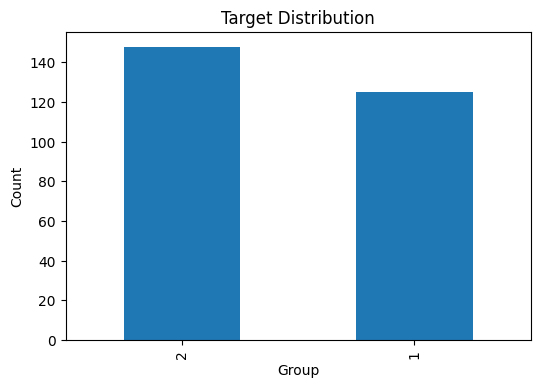


Class Distribution (%)
group
2    54.212454
1    45.787546
Name: proportion, dtype: float64


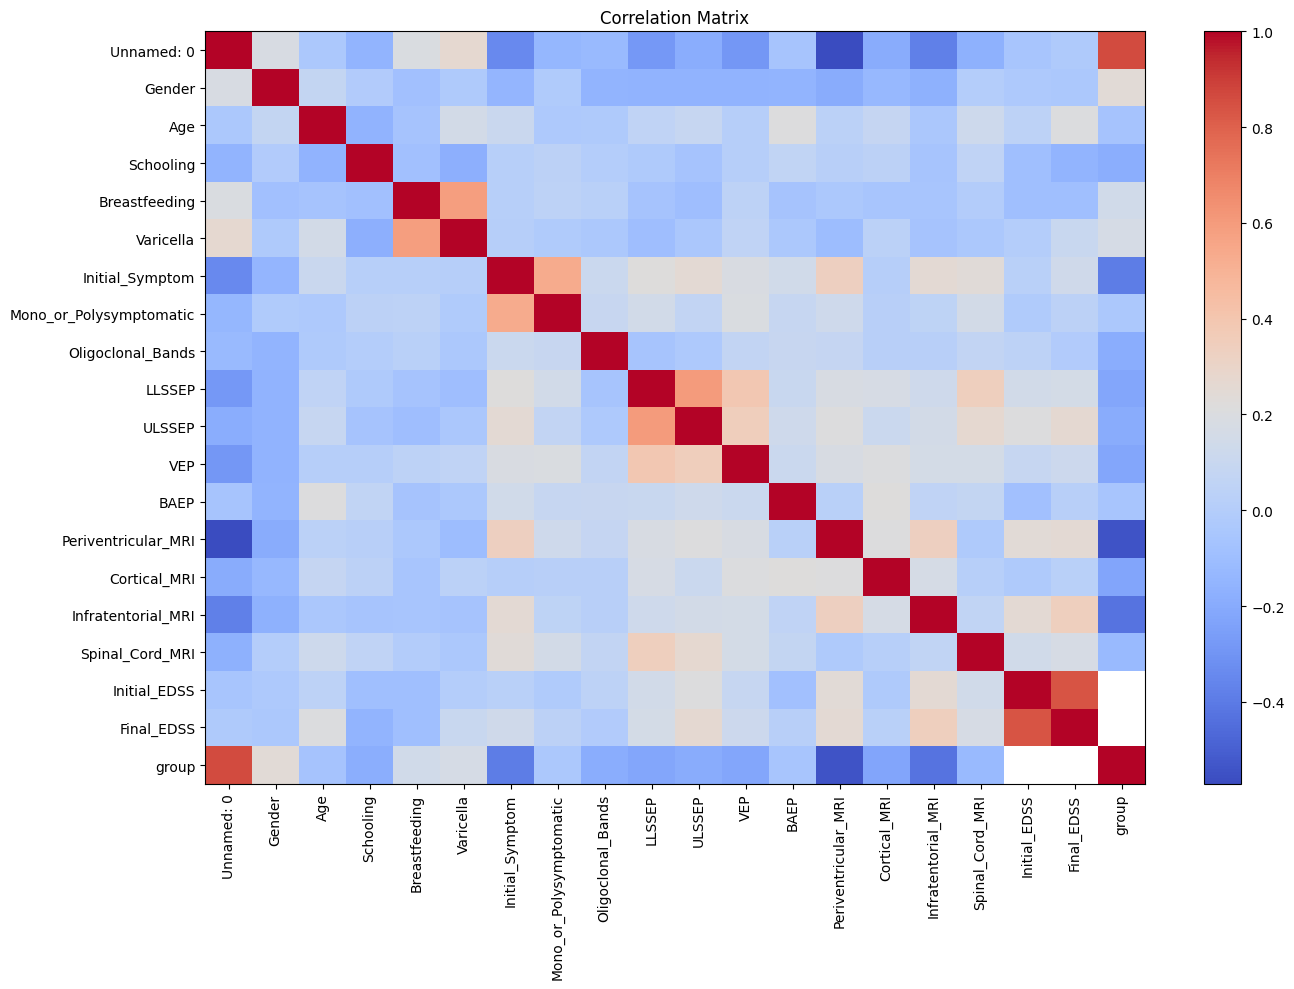


Numerical Columns
['Unnamed: 0', 'Gender', 'Age', 'Schooling', 'Breastfeeding', 'Varicella', 'Initial_Symptom', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP', 'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI', 'Initial_EDSS', 'Final_EDSS']


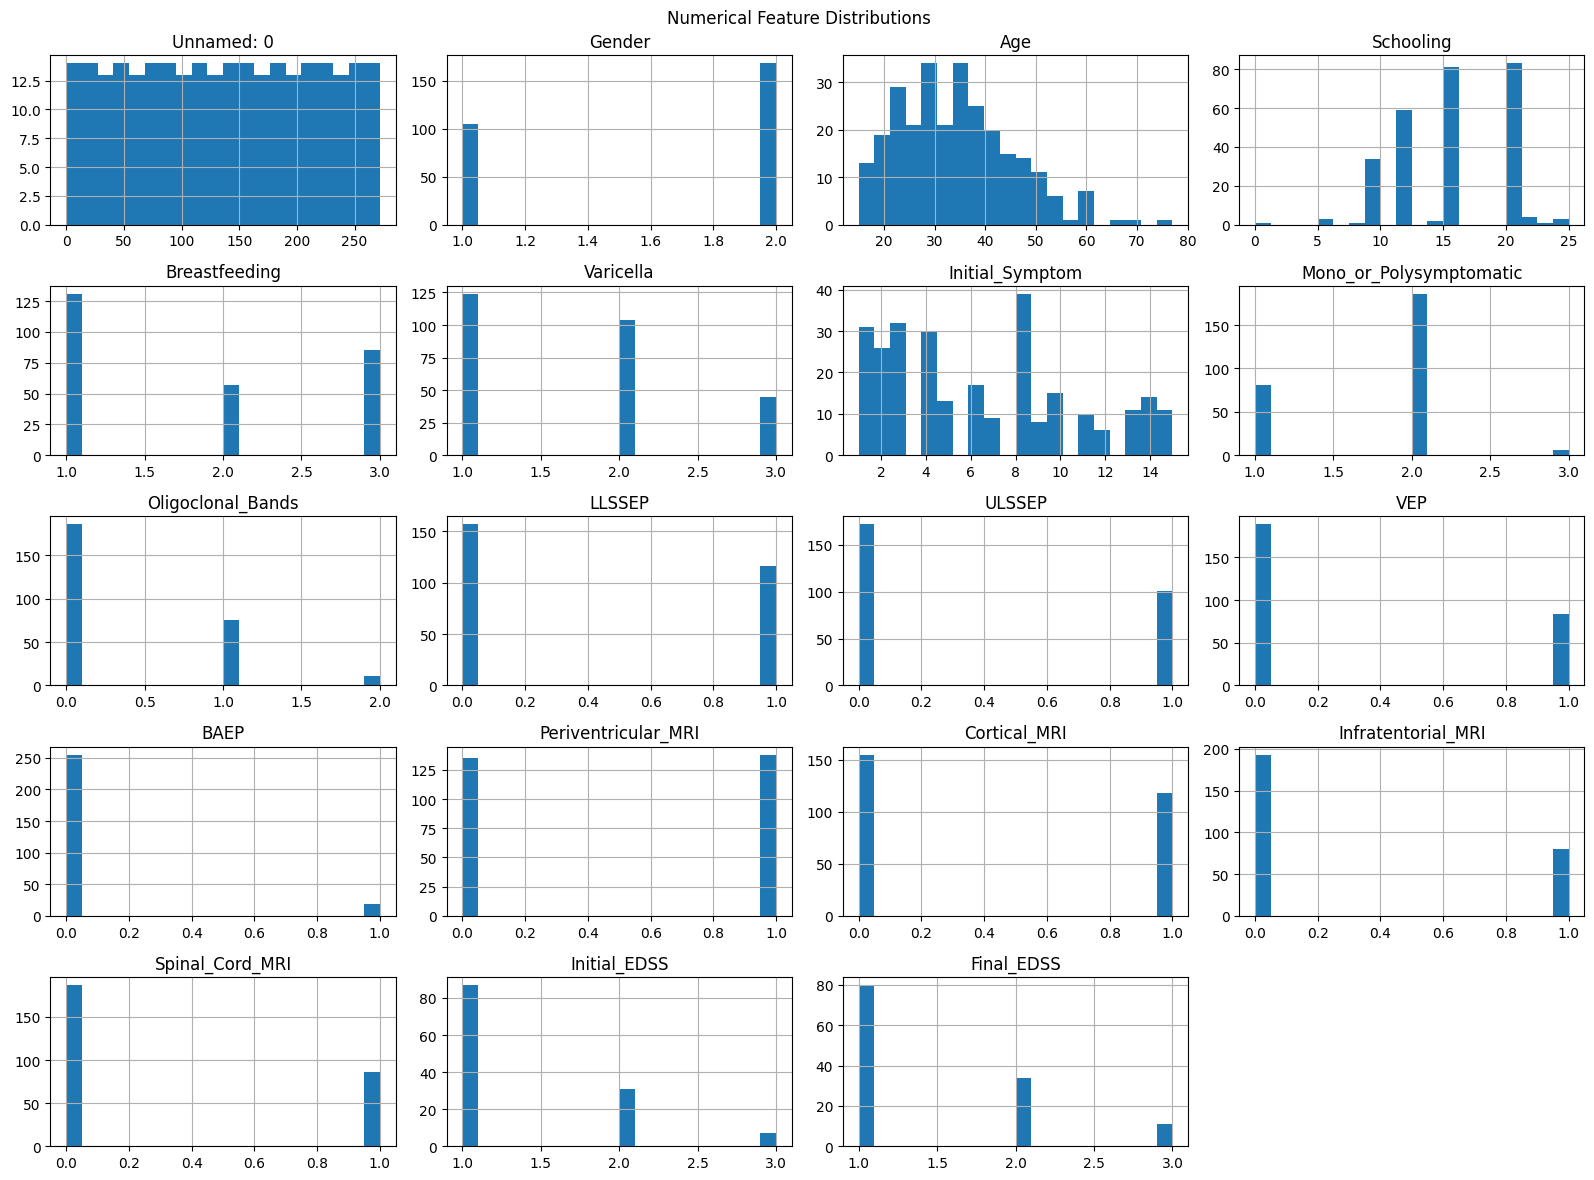

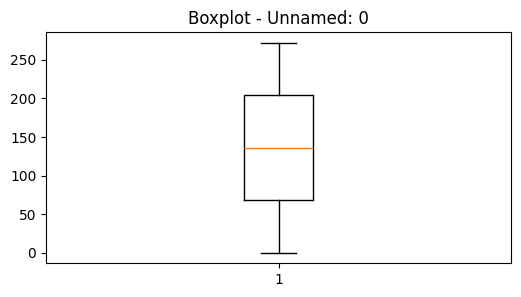

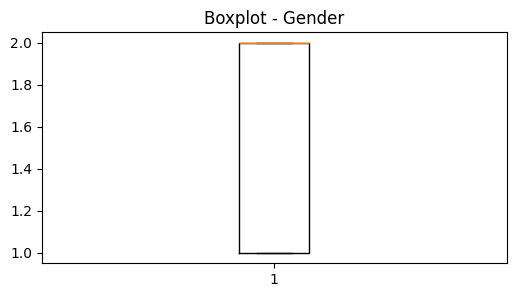

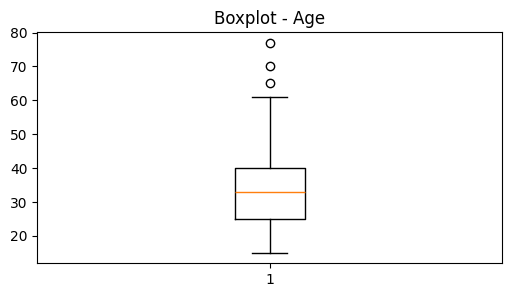

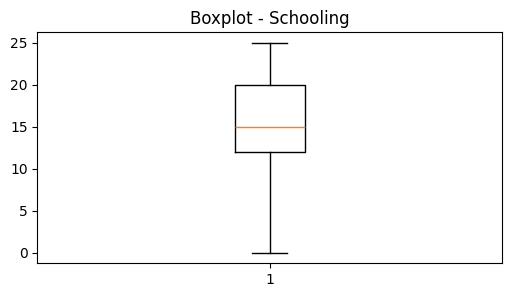

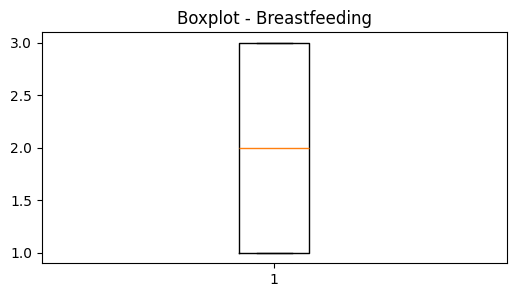

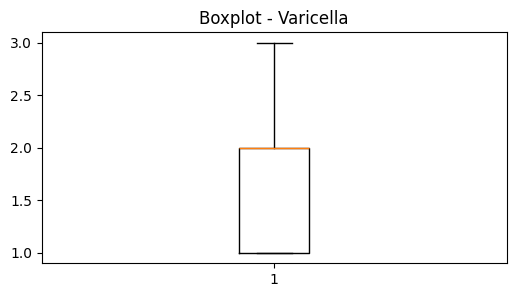

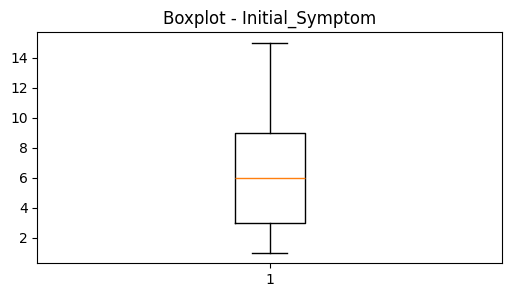

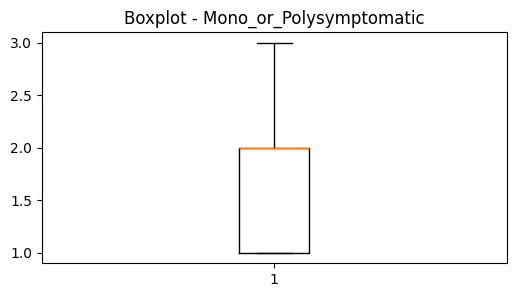

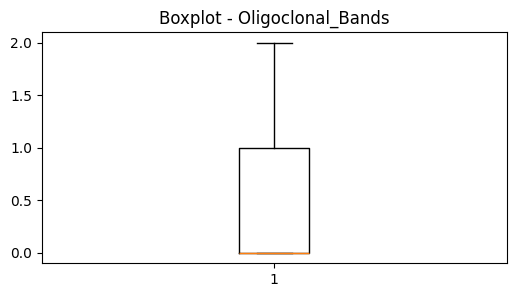

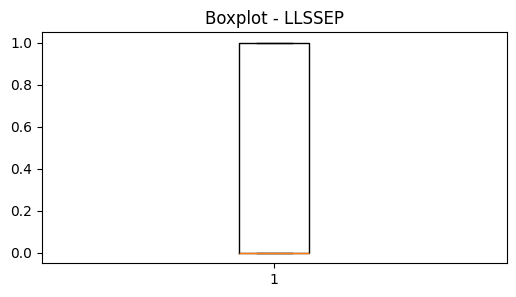

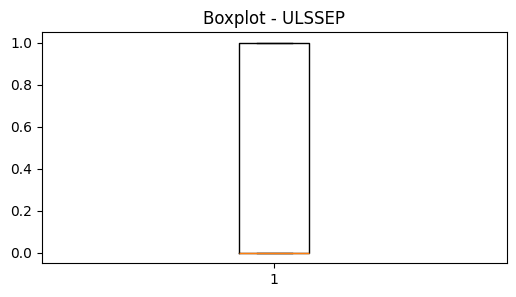

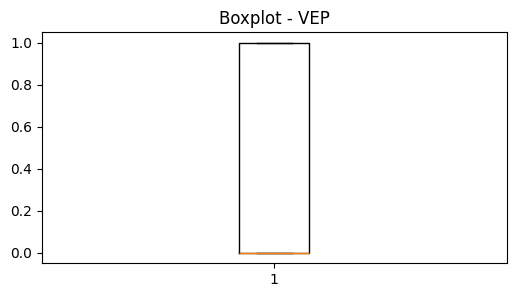

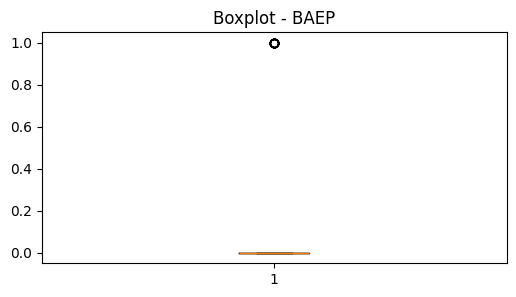

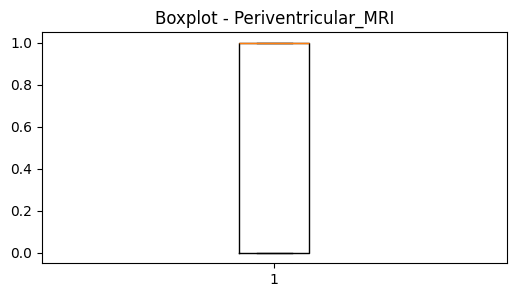

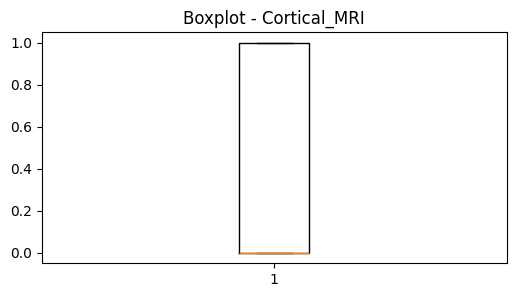

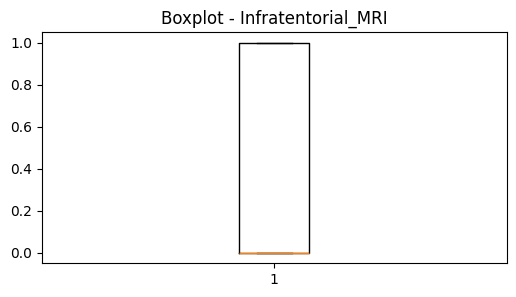

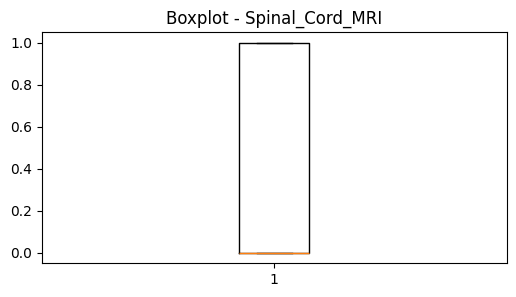

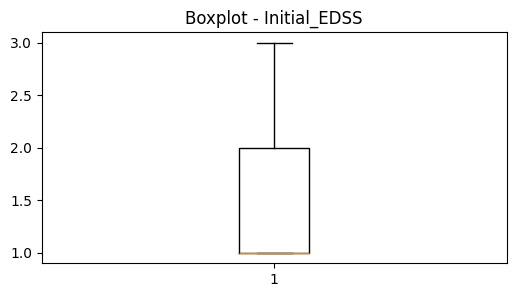

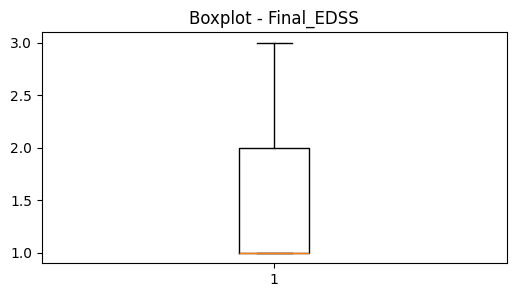


Categorical Columns
['Gender', 'Breastfeeding', 'Varicella', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP', 'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI', 'Initial_EDSS', 'Final_EDSS']


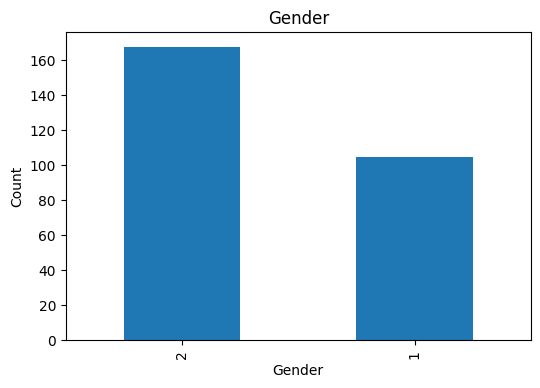

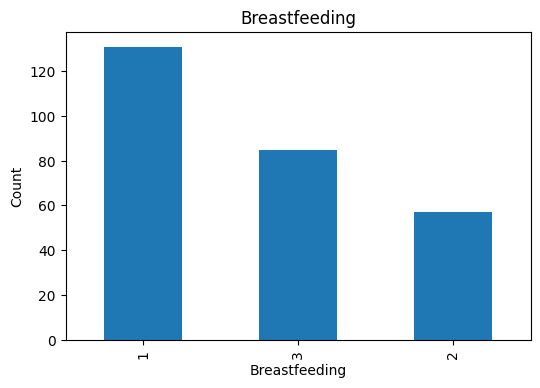

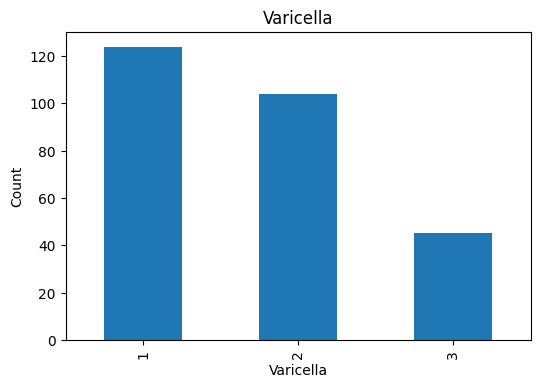

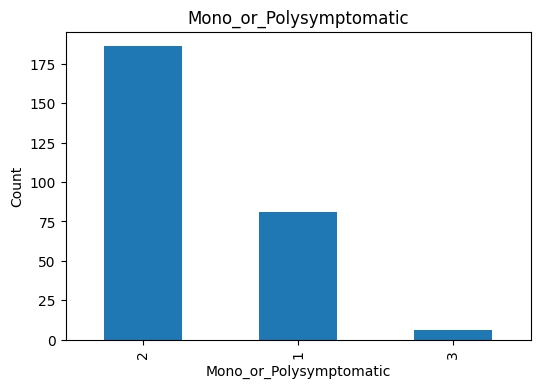

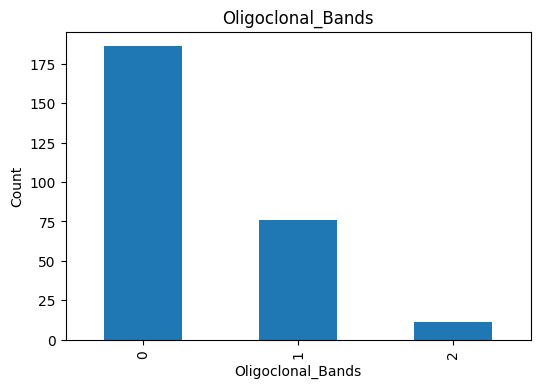

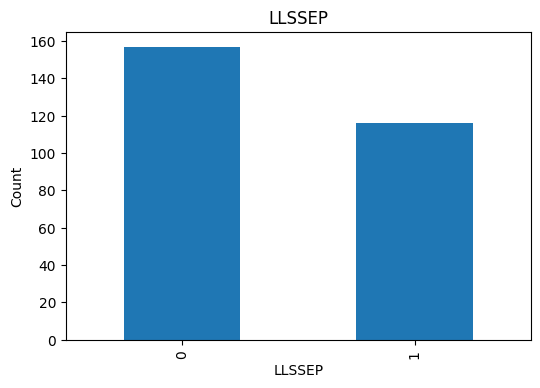

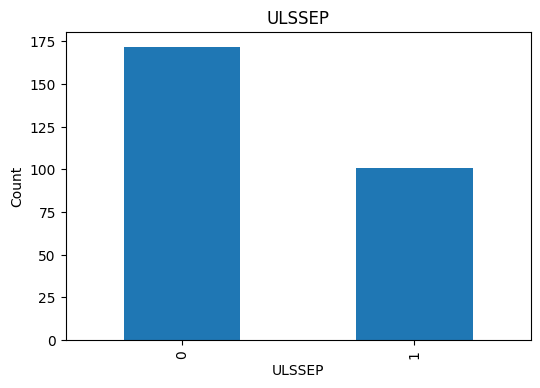

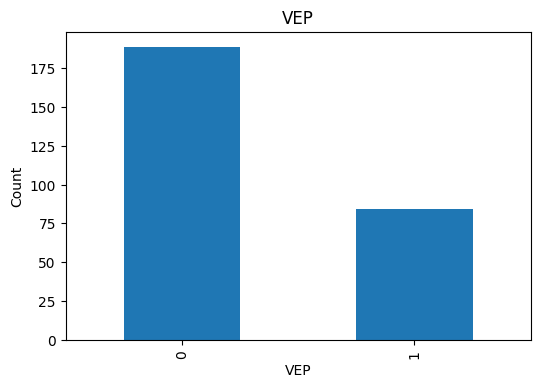

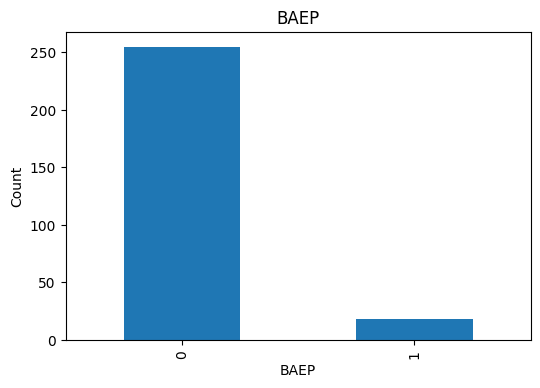

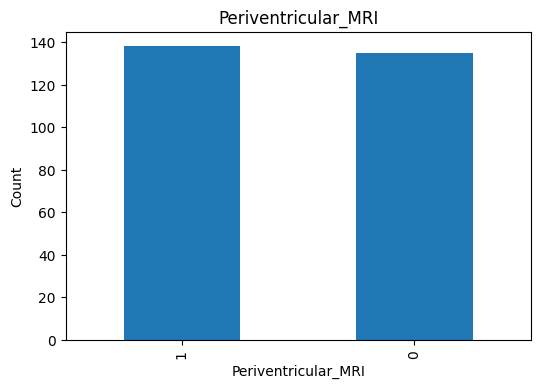

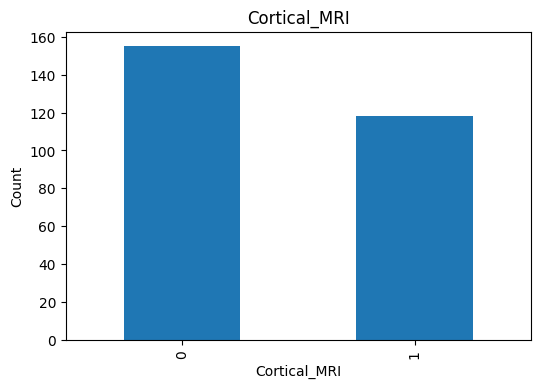

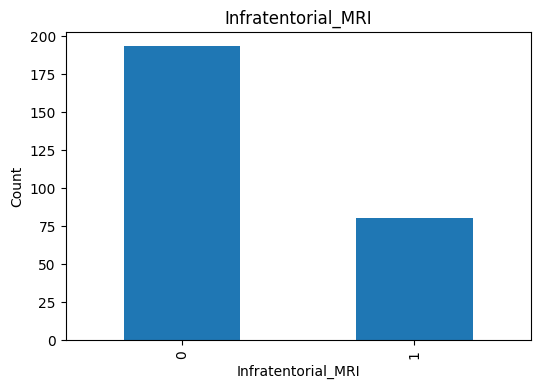

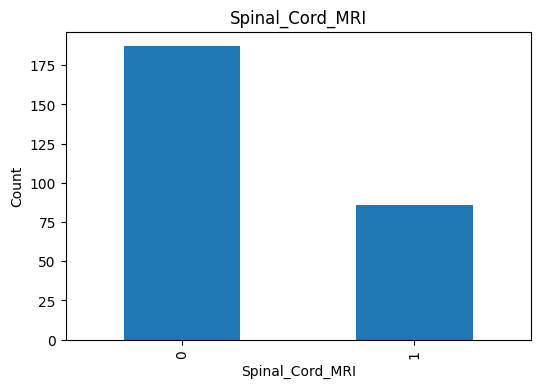

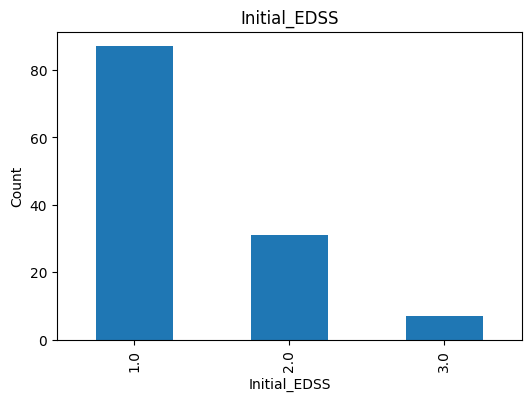

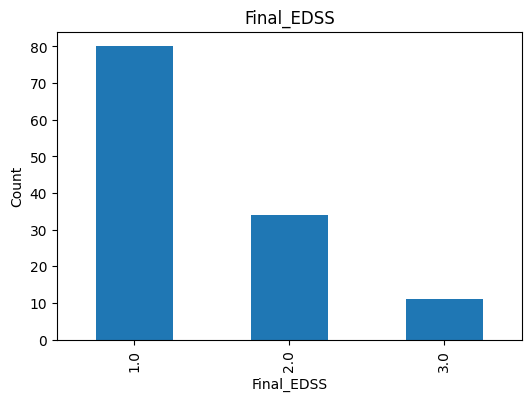

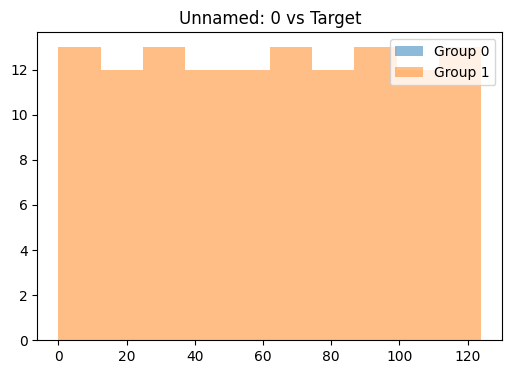

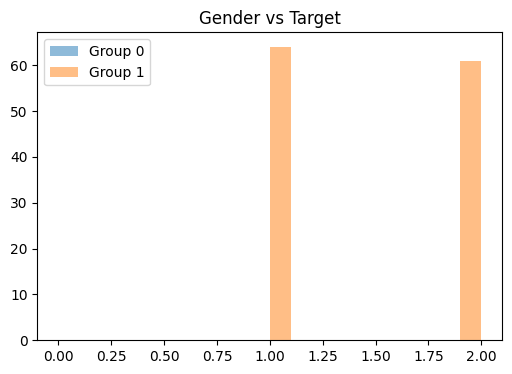

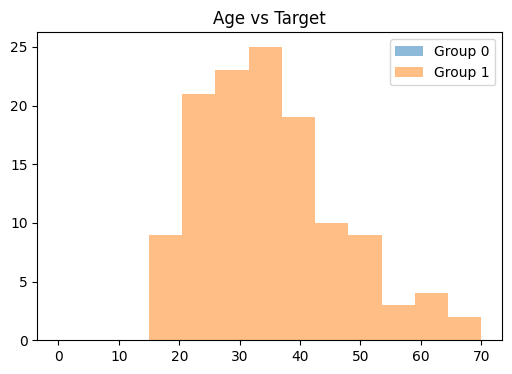

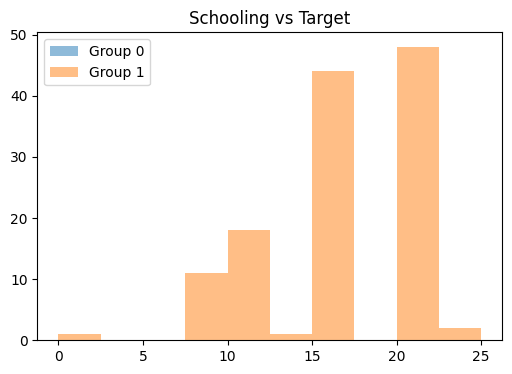

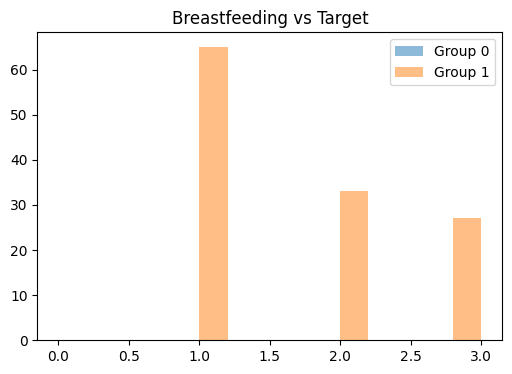

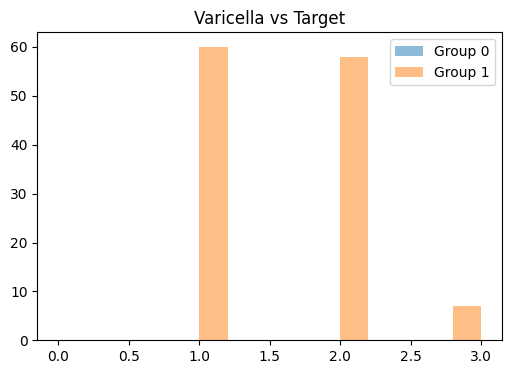

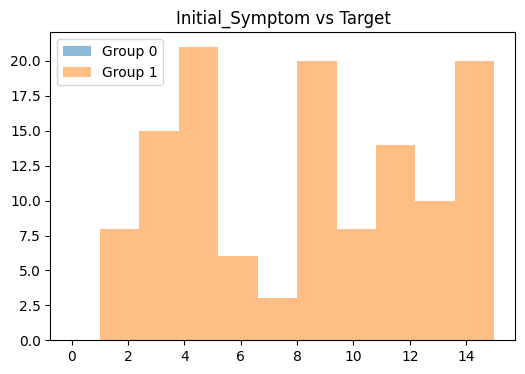

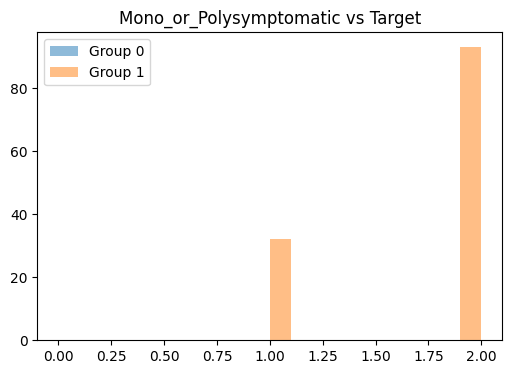

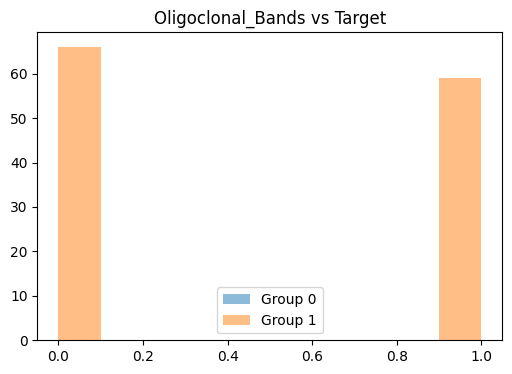

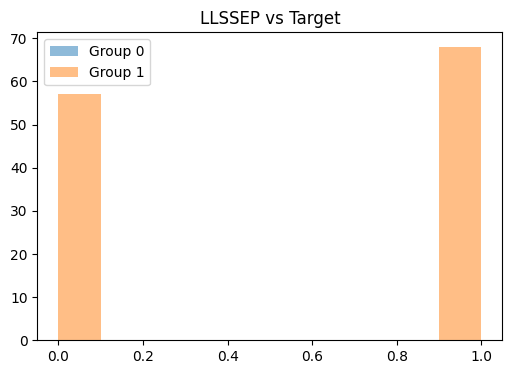

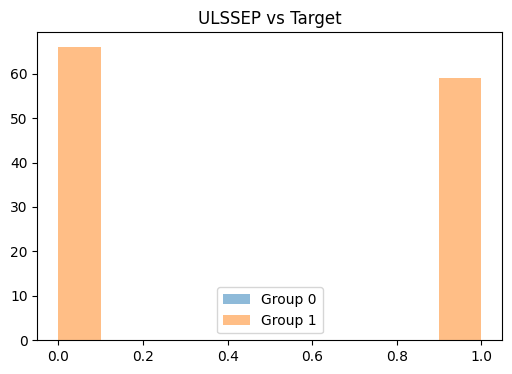

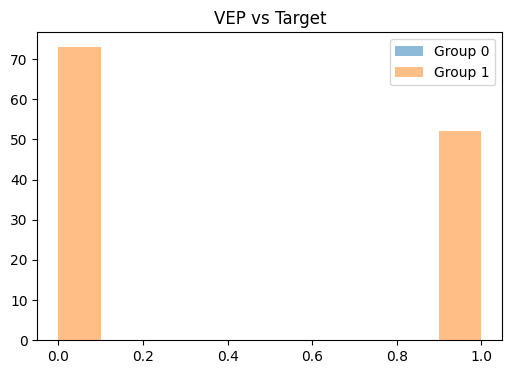

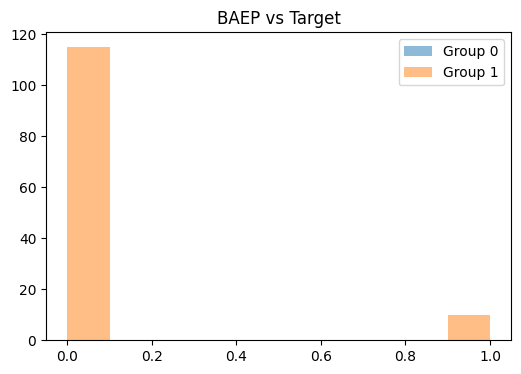

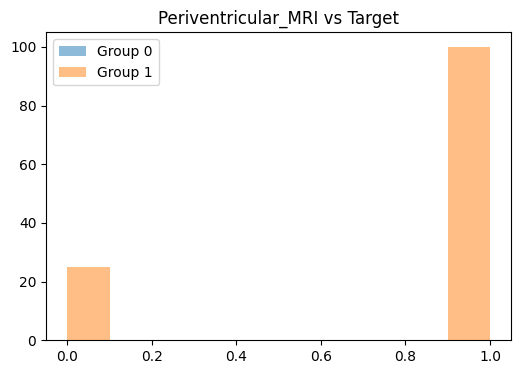

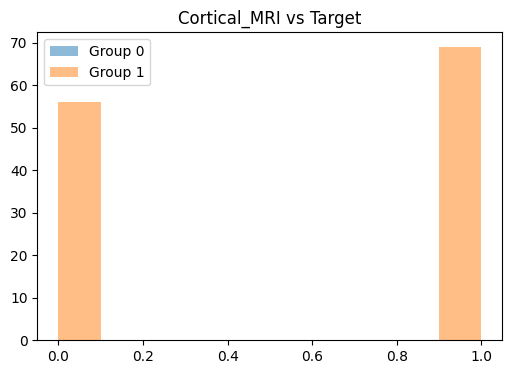

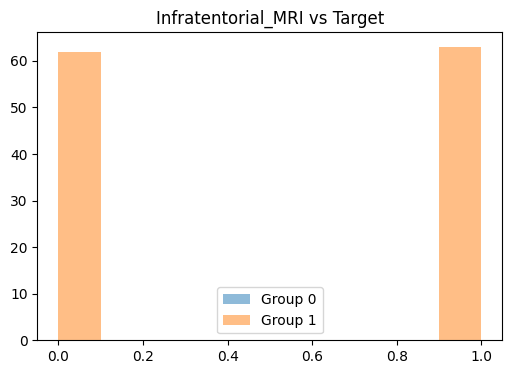

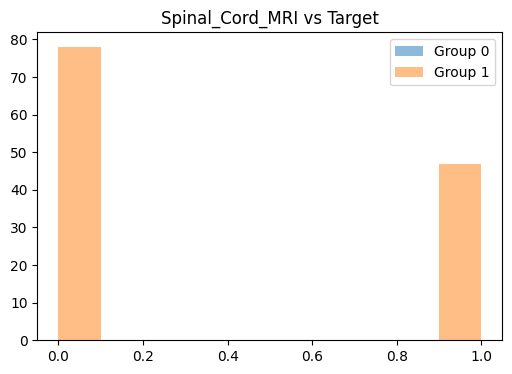

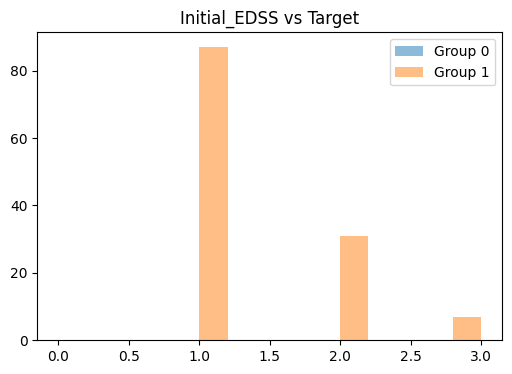

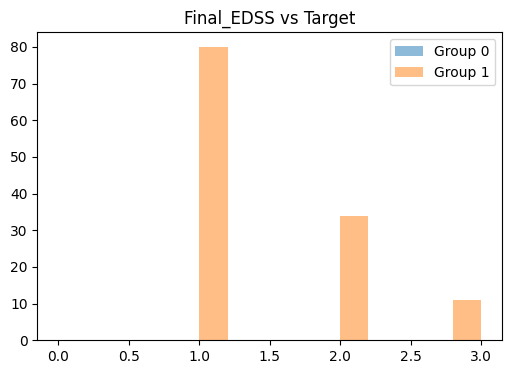


Outlier Counts
Unnamed: 0: 0
Gender: 0
Age: 3
Schooling: 0
Breastfeeding: 0
Varicella: 0
Initial_Symptom: 0
Mono_or_Polysymptomatic: 0
Oligoclonal_Bands: 0
LLSSEP: 0
ULSSEP: 0
VEP: 0
BAEP: 18
Periventricular_MRI: 0
Cortical_MRI: 0
Infratentorial_MRI: 0
Spinal_Cord_MRI: 0
Initial_EDSS: 0
Final_EDSS: 0

EDA Completed Successfully


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv(
    r"C:\Users\manis\Ginger_Gradient\clinical-intelligence-system\conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"
)

print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\nFirst 5 Rows")
print(df.head())

# ==========================
# Basic Information
# ==========================
print("\nDataset Info")
print(df.info())

print("\nData Types")
print(df.dtypes)

# ==========================
# Missing Values
# ==========================
print("\nMissing Values")
print(df.isnull().sum())

missing_percent = (df.isnull().sum()/len(df))*100
print("\nMissing Percentage")
print(missing_percent.sort_values(ascending=False))

# ==========================
# Duplicate Records
# ==========================
print("\nDuplicate Rows:", df.duplicated().sum())

# ==========================
# Statistical Summary
# ==========================
print("\nNumerical Summary")
print(df.describe().T)

# ==========================
# Target Distribution
# ==========================
plt.figure(figsize=(6,4))
df["group"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution (%)")
print(df["group"].value_counts(normalize=True)*100)

# ==========================
# Correlation Matrix
# ==========================
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# ==========================
# Numerical Features
# ==========================
num_cols = df.select_dtypes(include=np.number).columns.tolist()

if "group" in num_cols:
    num_cols.remove("group")

print("\nNumerical Columns")
print(num_cols)

# Histograms
df[num_cols].hist(
    figsize=(16,12),
    bins=20
)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.show()

# ==========================
# Categorical Features
# ==========================
cat_cols = [
    col for col in df.columns
    if df[col].nunique() < 10 and col != "group"
]

print("\nCategorical Columns")
print(cat_cols)

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# ==========================
# Feature vs Target
# ==========================
for col in num_cols:
    plt.figure(figsize=(6,4))

    group0 = df[df["group"] == 0][col]
    group1 = df[df["group"] == 1][col]

    plt.hist(group0, alpha=0.5, label="Group 0")
    plt.hist(group1, alpha=0.5, label="Group 1")

    plt.title(f"{col} vs Target")
    plt.legend()
    plt.show()

# ==========================
# Outlier Detection (IQR)
# ==========================
print("\nOutlier Counts")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    print(f"{col}: {outliers}")

print("\nEDA Completed Successfully")

SHAPE : (273, 23)

--- Data Types ---
Unnamed: 0                   int64
Gender                       int64
Age                          int64
Schooling                  float64
Breastfeeding                int64
Varicella                    int64
Initial_Symptom            float64
Mono_or_Polysymptomatic      int64
Oligoclonal_Bands            int64
LLSSEP                       int64
ULSSEP                       int64
VEP                          int64
BAEP                         int64
Periventricular_MRI          int64
Cortical_MRI                 int64
Infratentorial_MRI           int64
Spinal_Cord_MRI              int64
Initial_EDSS               float64
Final_EDSS                 float64
group                        int64
Group_Label                 object
Gender_Label                object
MP_Label                    object
dtype: object

--- Missing Values ---
Unnamed: 0                   0
Gender                       0
Age                          0
Schooling                 

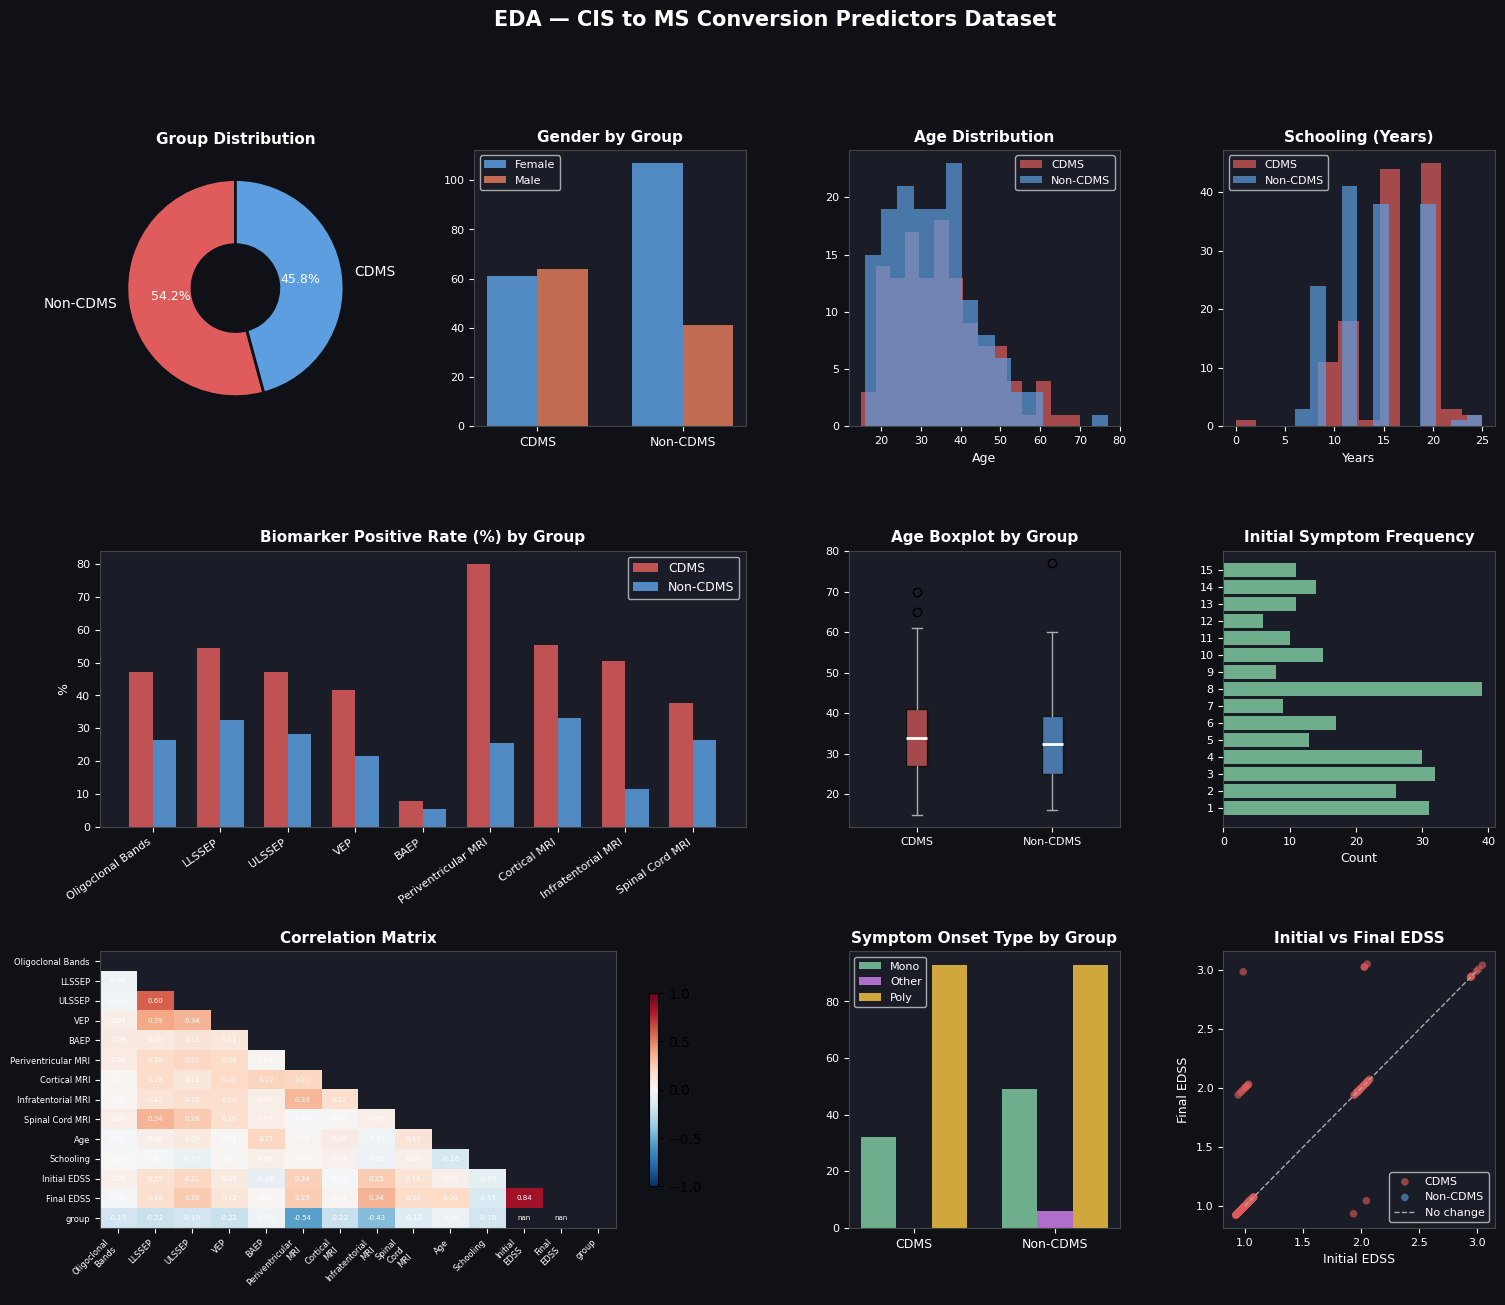

In [30]:
df['Group_Label']  = df['group'].map({1: 'CDMS', 2: 'Non-CDMS'})
df['Gender_Label'] = df['Gender'].map({1: 'Male', 2: 'Female'})
df['MP_Label']     = df['Mono_or_Polysymptomatic'].map({1: 'Mono', 2: 'Poly', 3: 'Other'})
 
# ── 2. Console Summary ────────────────────────────────────────────────────────
print("=" * 60)
print("SHAPE :", df.shape)
print("=" * 60)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe().round(2))
print("\n--- Target Distribution ---")
print(df['Group_Label'].value_counts())
print("\n--- Gender Distribution ---")
print(df['Gender_Label'].value_counts())
 
# ── 3. Column Groups ──────────────────────────────────────────────────────────
binary_cols = [
    'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP',
    'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI'
]
palette = {'CDMS': '#e05c5c', 'Non-CDMS': '#5c9ee0'}
 
# ── helper ────────────────────────────────────────────────────────────────────
def style(ax, title, xlabel=None, ylabel=None):
    ax.set_facecolor('#1a1d27')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white', labelsize=8)
    if xlabel: ax.set_xlabel(xlabel, color='white', fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color='white', fontsize=9)
    for s in ax.spines.values(): s.set_color('#444')
 
# ── 4. Dashboard ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)
 
# --- Plot 1: Group distribution (donut) -----
ax1 = fig.add_subplot(gs[0, 0])
sizes = df['Group_Label'].value_counts()
_, texts, autotexts = ax1.pie(
    sizes, labels=sizes.index, autopct='%1.1f%%',
    colors=['#e05c5c', '#5c9ee0'], startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='#0f1117', linewidth=2),
    textprops={'color': 'white', 'fontsize': 10}
)
for at in autotexts: at.set_fontsize(9)
ax1.set_title('Group Distribution', color='white', fontsize=11, fontweight='bold')
 
# --- Plot 2: Gender by group -----
ax2 = fig.add_subplot(gs[0, 1])
gender_group = df.groupby(['Group_Label', 'Gender_Label']).size().unstack(fill_value=0)
x = np.arange(len(gender_group)); w = 0.35
for i, (col, color) in enumerate(zip(gender_group.columns, ['#5c9ee0', '#e07a5c'])):
    ax2.bar(x + i*w - w/2, gender_group[col], w, color=color, label=col, alpha=0.85, edgecolor='none')
style(ax2, 'Gender by Group')
ax2.set_xticks(x); ax2.set_xticklabels(gender_group.index, color='white', fontsize=9)
ax2.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
 
# --- Plot 3: Age histogram -----
ax3 = fig.add_subplot(gs[0, 2])
for label, color in palette.items():
    ax3.hist(df[df['Group_Label'] == label]['Age'], bins=15,
             alpha=0.7, color=color, label=label, edgecolor='none')
style(ax3, 'Age Distribution', xlabel='Age')
ax3.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
 
# --- Plot 4: Schooling histogram -----
ax4 = fig.add_subplot(gs[0, 3])
for label, color in palette.items():
    ax4.hist(df[df['Group_Label'] == label]['Schooling'].dropna(), bins=12,
             alpha=0.7, color=color, label=label, edgecolor='none')
style(ax4, 'Schooling (Years)', xlabel='Years')
ax4.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
 
# --- Plot 5: Biomarker positive rates -----
ax5 = fig.add_subplot(gs[1, :2])
rates = df.groupby('Group_Label')[binary_cols].mean() * 100
x = np.arange(len(binary_cols)); w = 0.35
ax5.bar(x - w/2, rates.loc['CDMS'],     w, color='#e05c5c', label='CDMS',     alpha=0.85, edgecolor='none')
ax5.bar(x + w/2, rates.loc['Non-CDMS'], w, color='#5c9ee0', label='Non-CDMS', alpha=0.85, edgecolor='none')
style(ax5, 'Biomarker Positive Rate (%) by Group', ylabel='%')
ax5.set_xticks(x)
ax5.set_xticklabels([c.replace('_', ' ') for c in binary_cols],
                     rotation=35, ha='right', color='white', fontsize=8)
ax5.legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
 
# --- Plot 6: Age boxplot -----
ax6 = fig.add_subplot(gs[1, 2])
bp = ax6.boxplot(
    [df[df['Group_Label'] == 'CDMS']['Age'], df[df['Group_Label'] == 'Non-CDMS']['Age']],
    tick_labels=['CDMS', 'Non-CDMS'], patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#e05c5c', '#5c9ee0']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for el in ['whiskers', 'caps', 'fliers']:
    for item in bp[el]: item.set_color('#aaa')
style(ax6, 'Age Boxplot by Group')
 
# --- Plot 7: Initial symptom frequency -----
ax7 = fig.add_subplot(gs[1, 3])
sym_counts = df['Initial_Symptom'].value_counts().sort_index()
ax7.barh(sym_counts.index.astype(int).astype(str), sym_counts.values,
         color='#7ec8a0', edgecolor='none', alpha=0.85)
style(ax7, 'Initial Symptom Frequency', xlabel='Count')
 
# --- Plot 8: Correlation heatmap (pure matplotlib) -----
ax8 = fig.add_subplot(gs[2, :2])
corr_cols = binary_cols + ['Age', 'Schooling', 'Initial_EDSS', 'Final_EDSS', 'group']
corr = df[corr_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = np.where(mask, np.nan, corr.values)
im = ax8.imshow(corr_masked, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax8.set_facecolor('#1a1d27')
ax8.set_xticks(range(len(corr_cols)))
ax8.set_yticks(range(len(corr_cols)))
ax8.set_xticklabels([c.replace('_', '\n') for c in corr_cols],
                     fontsize=6, color='white', rotation=45, ha='right')
ax8.set_yticklabels([c.replace('_', ' ') for c in corr_cols], fontsize=6, color='white')
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        if not mask[i, j]:
            ax8.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                     fontsize=5, color='white')
plt.colorbar(im, ax=ax8, shrink=0.7)
ax8.set_title('Correlation Matrix', color='white', fontsize=11, fontweight='bold')
ax8.tick_params(colors='white')
for s in ax8.spines.values(): s.set_color('#444')
 
# --- Plot 9: Symptom onset type -----
ax9 = fig.add_subplot(gs[2, 2])
mp_group = df.groupby(['Group_Label', 'MP_Label']).size().unstack(fill_value=0)
x = np.arange(len(mp_group)); w = 0.25
for i, (col, color) in enumerate(zip(mp_group.columns, ['#7ec8a0', '#c97de8', '#f0c040'])):
    ax9.bar(x + i*w - w, mp_group[col], w, color=color, label=col, alpha=0.85, edgecolor='none')
style(ax9, 'Symptom Onset Type by Group')
ax9.set_xticks(x); ax9.set_xticklabels(mp_group.index, color='white', fontsize=9)
ax9.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
 
# --- Plot 10: Initial vs Final EDSS scatter -----
ax10 = fig.add_subplot(gs[2, 3])
edss_df = df[['Initial_EDSS', 'Final_EDSS', 'Group_Label']].dropna()
rng = np.random.default_rng(42)
for label, color in palette.items():
    sub = edss_df[edss_df['Group_Label'] == label]
    jitter = rng.uniform(-0.08, 0.08, len(sub))
    ax10.scatter(sub['Initial_EDSS'] + jitter, sub['Final_EDSS'] + jitter,
                 c=color, alpha=0.6, s=30, edgecolors='none', label=label)
ax10.plot([1, 3], [1, 3], '--', color='#aaa', linewidth=1, label='No change')
style(ax10, 'Initial vs Final EDSS', xlabel='Initial EDSS', ylabel='Final EDSS')
ax10.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
 
# ── 5. Save / Show ────────────────────────────────────────────────────────────
fig.suptitle('EDA — CIS to MS Conversion Predictors Dataset',
             color='white', fontsize=15, fontweight='bold', y=0.98)
 
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
print("Saved → eda_dashboard.png")
plt.show()
 

In [3]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score,
)

2.Load dataset


In [4]:
df = pd.read_csv(r"C:\Users\manis\Ginger_Gradient\clinical-intelligence-system\conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"
)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (273, 20)


,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


3.Exploratory data analysis

In [5]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               273 non-null    int64  
 1   Gender                   273 non-null    int64  
 2   Age                      273 non-null    int64  
 3   Schooling                272 non-null    float64
 4   Breastfeeding            273 non-null    int64  
 5   Varicella                273 non-null    int64  
 6   Initial_Symptom          272 non-null    float64
 7   Mono_or_Polysymptomatic  273 non-null    int64  
 8   Oligoclonal_Bands        273 non-null    int64  
 9   LLSSEP                   273 non-null    int64  
 10  ULSSEP                   273 non-null    int64  
 11  VEP                      273 non-null    int64  
 12  BAEP                     273 non-null    int64  
 13  Periventricular_MRI      273 non-null    int64  
 14  Cortical_MRI             2

In [13]:
numerical_features = [
     "Age",
    "Schooling",
    "Initial_EDSS",
    "Final_EDSS"
]

categorical_features = [
    "Gender",
    "Breastfeeding",
    "Varicella",
    "Initial_Symptom",
    "Mono_or_Polysymptomatic",
    "Oligoclonal_Bands",
    "LLSSEP",
    "ULSSEP",
    "VEP",
    "BAEP",
    "Periventricular_MRI",
    "Cortical_MRI",
    "Infratentorial_MRI",
    "Spinal_Cord_MRI"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Schooling', 'Initial_EDSS', 'Final_EDSS']
Categorical features: ['Gender', 'Breastfeeding', 'Varicella', 'Initial_Symptom', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP', 'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI']


In [6]:
# missing values
df.isna().sum().sort_values()

Unnamed: 0                   0
Spinal_Cord_MRI              0
Infratentorial_MRI           0
Cortical_MRI                 0
Periventricular_MRI          0
BAEP                         0
VEP                          0
ULSSEP                       0
LLSSEP                       0
Mono_or_Polysymptomatic      0
Varicella                    0
Breastfeeding                0
Age                          0
Gender                       0
Oligoclonal_Bands            0
group                        0
Initial_Symptom              1
Schooling                    1
Final_EDSS                 148
Initial_EDSS               148
dtype: int64

In [7]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Unnamed: 0
0      1
180    1
186    1
185    1
184    1
183    1
182    1
181    1
179    1
137    1
Name: count, dtype: int64
Gender
2    168
1    105
Name: count, dtype: int64
Age
28    16
24    15
34    14
38    11
40    11
29    11
36    11
22    10
31    10
35     9
Name: count, dtype: int64
Schooling
20.0    83
15.0    81
12.0    59
9.0     34
22.0     4
6.0      3
25.0     2
14.0     2
0.0      1
23.0     1
Name: count, dtype: int64
Breastfeeding
1    131
3     85
2     57
Name: count, dtype: int64
Varicella
1    124
2    104
3     45
Name: count, dtype: int64
Initial_Symptom
8.0     39
3.0     32
1.0     31
4.0     30
2.0     26
6.0     17
10.0    15
14.0    14
5.0     13
15.0    11
Name: count, dtype: int64
Mono_or_Polysymptomatic
2    186
1     81
3      6
Name: count, dtype: int64
Oligoclonal_Bands
0    186
1     76
2     11
Name: count, dtype: int64
LLSSEP
0    157
1    116
Name: count, dtype: int64
ULSSEP
0    172
1    101
Name: count, dtype: int64
VEP
0    189
1     84
Na

In [8]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


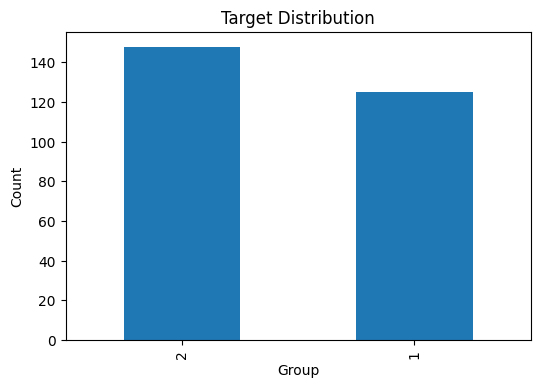


Class Distribution (%)
group
2    54.212454
1    45.787546
Name: proportion, dtype: float64


In [ ]:
# visualize target distribution
plt.figure(figsize=(6,4))
df["group"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution (%)")
print(df["group"].value_counts(normalize=True)*100)

In [11]:
df["group"] = df["group"].map({1:0, 2:1})

In [12]:
print(df["group"].value_counts())

group
1    148
0    125
Name: count, dtype: int64


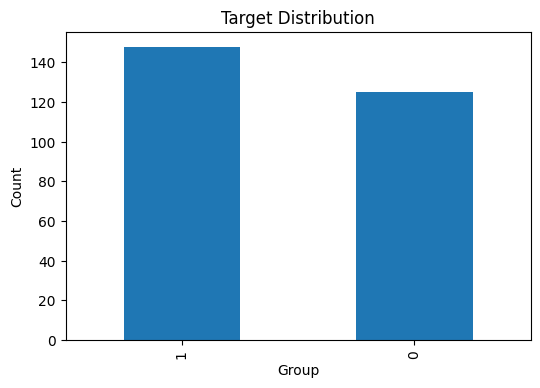


Class Distribution (%)
group
1    54.212454
0    45.787546
Name: proportion, dtype: float64


In [14]:
# visualize target distribution
plt.figure(figsize=(6,4))
df["group"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution (%)")
print(df["group"].value_counts(normalize=True)*100)

Balanced dataset

In [15]:
df[numerical_features].describe()

,Age,Schooling,Initial_EDSS,Final_EDSS
count,273.000000,272.000000,125.000000,125.00000
mean,34.062271,15.176471,1.360000,1.44800
std,11.114369,4.244175,0.587504,0.65323
min,15.000000,0.000000,1.000000,1.00000
25%,25.000000,12.000000,1.000000,1.00000
50%,33.000000,15.000000,1.000000,1.00000
75%,40.000000,20.000000,2.000000,2.00000
max,77.000000,25.000000,3.000000,3.00000


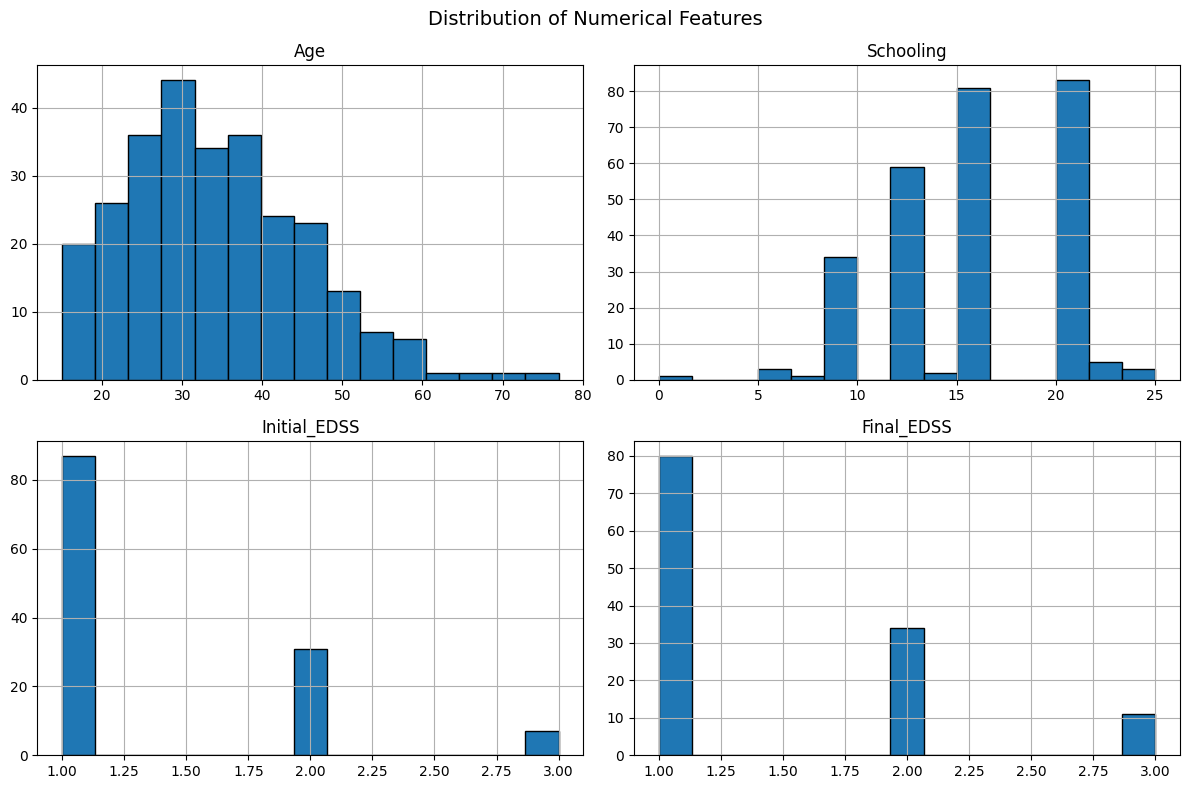

In [17]:
import matplotlib.pyplot as plt

# Numerical columns
numerical_features = [
    "Age",
    "Schooling",
    "Initial_EDSS",
    "Final_EDSS"
]

# Create histograms
df[numerical_features].hist(
    figsize=(12,8),
    bins=15,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

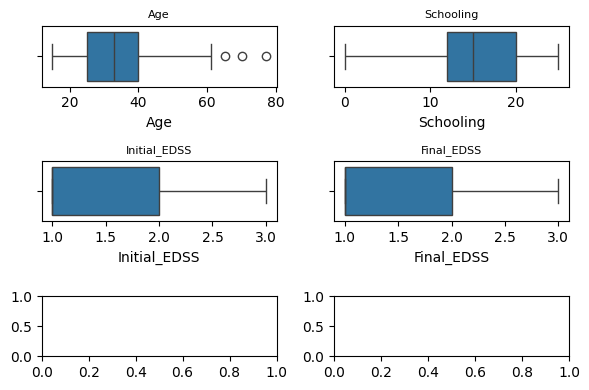

In [19]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

No much outliers,we can leave as it is.

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\manis\Ginger_Gradient\clinical-intelligence-system\conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"
)

print(df.shape)
df.head()

(273, 20)


,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


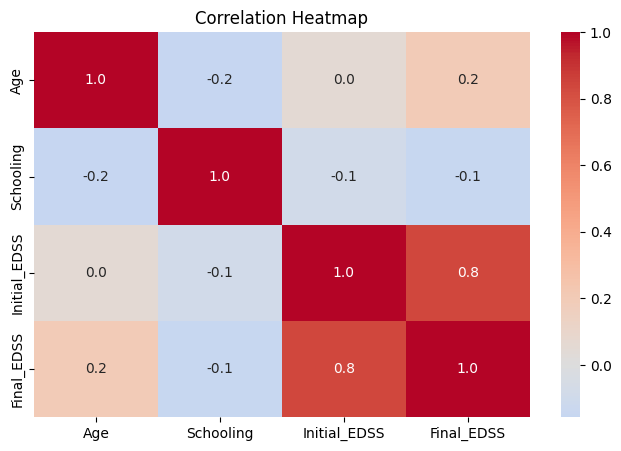

In [ ]:
# identify presence of highly correlated columns & feature relationships
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.heatmap(
    df[numerical_features].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

Initial_EDSS and Final_EDSS are highly correlated (r = 0.80).

In [ ]:
4. Data preprocessing

In [11]:
# Separate X and y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Create a signature for each feature row - to prevent duplicates flow to test set
row_signature = pd.util.hash_pandas_object(X, index=False)

In [16]:
# Split data into train and test sets using GroupShuffleSplit
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=row_signature)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (232, 18)
Test shape: (41, 18)


In [17]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (273, 18)
Train Dataset size (232, 18)
Test Dataset size (41, 18)
